<a href="https://colab.research.google.com/github/Sultan-al-islam/audio-codec/blob/main/Thisis(main)_prectice_BanglaAudio_Data_Set.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Imports necessary libraries for audio processing, neural networks, and data handling.
import os
import torch
import torch.nn as nn
import torch.optim as optim
import librosa
import numpy as np
import soundfile as sf
from torch.utils.data import DataLoader, Dataset
from google.colab import drive

In [2]:
# Mounts Google Drive to access files.
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
AUDIO_FOLDER = '/content/drive/MyDrive/Bangla_3sec_audio/processed_3sec'
SAVE_PATH = '/content/drive/MyDrive/AudioOutput'
os.makedirs(SAVE_PATH, exist_ok=True)

In [4]:
# Defines a custom Dataset class to load and preprocess audio files into fixed-length segments.
class Dataset(Dataset):
    def __init__(self, folder_path, segment_length=1024):
        self.segment_length = segment_length
        self.data = []

        print("Preprocessing audio files into mono 44.1kHz...")
        files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]

        for file in files:
            file_path = os.path.join(folder_path, file)
            audio, _ = librosa.load(file_path, sr=44100, mono=True)
            if np.max(np.abs(audio)) > 0:
                audio = audio / np.max(np.abs(audio))

            for i in range(0, len(audio) - segment_length, segment_length):
                self.data.append(audio[i : i + segment_length])

        self.data = np.array(self.data)
        print(f"Total audio segments prepared: {len(self.data)}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return torch.FloatTensor(self.data[idx])

In [5]:
# Defines the AudioVAE (Variational Autoencoder) model architecture.
class AudioVAE(nn.Module):
    def __init__(self, input_dim=1024, hidden_dim=512, latent_dim=64):
        super(AudioVAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LeakyReLU(0.2)
        )
        self.fc_mu = nn.Linear(hidden_dim // 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim // 2, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, input_dim),
            nn.Tanh()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

In [6]:
# Defines a function to calculate an accuracy score based on cosine similarity between original and reconstructed audio.
def calculate_accuracy_score(original, reconstructed):
    if np.linalg.norm(original) == 0 or np.linalg.norm(reconstructed) == 0:
        return 0.0
    cosine_sim = np.dot(original, reconstructed) / (np.linalg.norm(original) * np.linalg.norm(reconstructed))
    accuracy_score = (cosine_sim + 1) / 2
    return accuracy_score

In [7]:
# Defines the VAE loss function, combining Mean Squared Error (MSE) and Kullback-Leibler Divergence (KLD).
def vae_loss(recon_x, x, mu, logvar):
    MSE = nn.functional.mse_loss(recon_x, x, reduction='mean')
    KLD = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE + 0.001 * KLD

In [10]:
# Defines the training loop for the VAE model and then executes it.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def train():
    dataset = Dataset(AUDIO_FOLDER)
    dataloader = DataLoader(dataset, batch_size=128, shuffle=True)
    model = AudioVAE().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    print("Starting Training (30 Epochs)...")
    for epoch in range(30):
        model.train()
        total_loss = 0
        for batch in dataloader:
            batch = batch.to(device)
            optimizer.zero_grad()
            recon, mu, logvar = model(batch)
            loss = vae_loss(recon, batch, mu, logvar)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch+1} Complete. Avg Loss: {avg_loss:.8f}")
    return model, dataset
trained_model, dataset = train()

Preprocessing audio files into mono 44.1kHz...
Total audio segments prepared: 562440
Starting Training (30 Epochs)...
Epoch 1 Complete. Avg Loss: 0.01133531
Epoch 2 Complete. Avg Loss: 0.00664281
Epoch 3 Complete. Avg Loss: 0.00582546
Epoch 4 Complete. Avg Loss: 0.00535267
Epoch 5 Complete. Avg Loss: 0.00511195
Epoch 6 Complete. Avg Loss: 0.00492483
Epoch 7 Complete. Avg Loss: 0.00482580
Epoch 8 Complete. Avg Loss: 0.00476646
Epoch 9 Complete. Avg Loss: 0.00471855
Epoch 10 Complete. Avg Loss: 0.00466680
Epoch 11 Complete. Avg Loss: 0.00461854
Epoch 12 Complete. Avg Loss: 0.00457967
Epoch 13 Complete. Avg Loss: 0.00455184
Epoch 14 Complete. Avg Loss: 0.00452548
Epoch 15 Complete. Avg Loss: 0.00449813
Epoch 16 Complete. Avg Loss: 0.00447640
Epoch 17 Complete. Avg Loss: 0.00445990
Epoch 18 Complete. Avg Loss: 0.00444604
Epoch 19 Complete. Avg Loss: 0.00443327
Epoch 20 Complete. Avg Loss: 0.00442168
Epoch 21 Complete. Avg Loss: 0.00440749
Epoch 22 Complete. Avg Loss: 0.00439194
Epoch 23 Co

In [14]:
import IPython.display as ipd
import random

def play_random_samples(model, dataset, num_samples=3):
    model.eval()
    with torch.no_grad():
        for i in range(num_samples):
            # Dataset theke random ekta index select kora hochche
            idx = random.randint(0, len(dataset) - 130) # 130 segments roughly 3 seconds

            original_segments = []
            reconstructed_segments = []

            # 3 second-er moto audio bananor jonno porpor kichu segment nichi
            # Apnar segment length 1024, tai pray 129 segment = 3 sec (44.1kHz e)
            for j in range(idx, idx + 129):
                original = dataset[j].unsqueeze(0).to(device)
                recon, _, _ = model(original)

                original_segments.append(original.cpu().squeeze().numpy())
                reconstructed_segments.append(recon.cpu().squeeze().numpy())

            # Shob gulo segment eksathe jora lagano hochche
            full_original = np.concatenate(original_segments)
            full_recon = np.concatenate(reconstructed_segments)

            print(f"\n--- Sample {i+1} (Index: {idx}) ---")
            print("Original Audio:")
            display(ipd.Audio(full_original, rate=44100))

            print("Reconstructed Audio:")
            display(ipd.Audio(full_recon, rate=44100))

            # Accuracy calculate kora hochche
            score = calculate_accuracy_score(full_original, full_recon)
            print(f"Cosine Similarity Accuracy: {score:.4f}")
            print("-" * 30)

# Function-ti call kora hochche
play_random_samples(trained_model, dataset)


--- Sample 1 (Index: 125537) ---
Original Audio:


Reconstructed Audio:


Cosine Similarity Accuracy: 0.9605
------------------------------

--- Sample 2 (Index: 419877) ---
Original Audio:


Reconstructed Audio:


Cosine Similarity Accuracy: 0.9789
------------------------------

--- Sample 3 (Index: 197301) ---
Original Audio:


Reconstructed Audio:


Cosine Similarity Accuracy: 0.9837
------------------------------


In [15]:
def calculate_overall_accuracy(model, dataset, num_samples=1000):
    model.eval()
    scores = []

    print(f"Calculating average accuracy for {num_samples} random segments...")

    with torch.no_grad():
        for _ in range(num_samples):
            # র‍্যান্ডম ইনডেক্স থেকে একটি সেগমেন্ট নেওয়া
            idx = random.randint(0, len(dataset) - 1)
            original = dataset[idx].unsqueeze(0).to(device)

            # মডেলের মাধ্যমে রিকনস্ট্রাকশন
            recon, _, _ = model(original)

            # টেনসর থেকে নামপাই অ্যারেতে কনভার্ট
            orig_np = original.cpu().squeeze().numpy()
            recon_np = recon.cpu().squeeze().numpy()

            # আপনার নোটবুকে থাকা ফাংশনটি ব্যবহার করা হচ্ছে
            score = calculate_accuracy_score(orig_np, recon_np)
            scores.append(score)

    avg_score = np.mean(scores)
    print(f"\n================================")
    print(f"Average Accuracy Score: {avg_score:.4f}")
    print(f"Percentage Match: {avg_score * 100:.2f}%")
    print(f"================================")

# রান করুন
calculate_overall_accuracy(trained_model, dataset)

Calculating average accuracy for 1000 random segments...

Average Accuracy Score: 0.8082
Percentage Match: 80.82%


In [17]:
def calculate_snr_metrics(model, dataset, num_samples=1000):
    model.eval()
    snr_values = []
    psnr_values = []

    print(f"Calculating SNR and PSNR for {num_samples} samples...")

    with torch.no_grad():
        for _ in range(num_samples):
            idx = random.randint(0, len(dataset) - 1)
            original = dataset[idx].cpu().numpy()

            # মডেল প্রেডিকশন
            input_tensor = torch.FloatTensor(original).unsqueeze(0).to(device)
            recon, _, _ = model(input_tensor)
            reconstructed = recon.cpu().squeeze().numpy()

            # Noise (Error) ক্যালকুলেশন
            noise = original - reconstructed

            # SNR ক্যালকুলেশন
            signal_power = np.sum(original**2)
            noise_power = np.sum(noise**2)

            if noise_power > 0 and signal_power > 0:
                snr = 10 * np.log10(signal_power / noise_power)
                snr_values.append(snr)

                # PSNR ক্যালকুলেশন (অডিওর ম্যাক্সিমাম ভ্যালু ১ ধরে)
                mse = np.mean(noise**2)
                if mse > 0:
                    psnr = 10 * np.log10(1**2 / mse)
                    psnr_values.append(psnr)

    avg_snr = np.mean(snr_values)
    avg_psnr = np.mean(psnr_values)

    print(f"\n--- Noise Ratio Results ---")
    print(f"Average SNR: {avg_snr:.2f} dB")
    print(f"Average PSNR: {avg_psnr:.2f} dB")
    print(f"---------------------------")



# রান করুন
calculate_snr_metrics(trained_model, dataset)

Calculating SNR and PSNR for 1000 samples...

--- Noise Ratio Results ---
Average SNR: 6.17 dB
Average PSNR: 29.82 dB
---------------------------


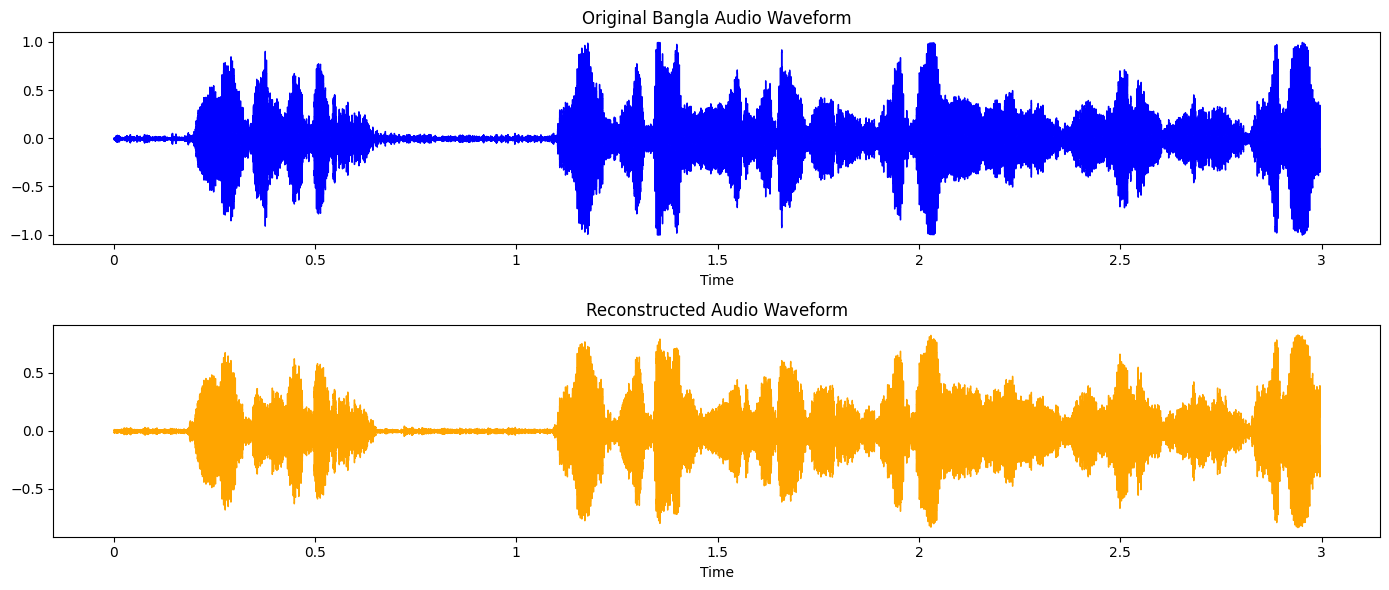

In [23]:
import librosa.display
import random

trained_model.eval()
with torch.no_grad():
    # র‍্যান্ডম ৩ সেকেন্ডের স্যাম্পল তৈরি
    idx = random.randint(0, len(dataset) - 130)
    orig_segments = [dataset[i].numpy() for i in range(idx, idx + 129)]
    full_original = np.concatenate(orig_segments)

    recon_segments = []
    for i in range(idx, idx + 129):
        seg = dataset[i].unsqueeze(0).to(device)
        recon_seg, _, _ = trained_model(seg)
        recon_segments.append(recon_seg.cpu().squeeze().numpy())
    full_recon = np.concatenate(recon_segments)

# Waveform Plotting
plt.figure(figsize=(14, 6))
plt.subplot(2, 1, 1)
librosa.display.waveshow(full_original, sr=44100, color='blue')
plt.title('Original Bangla Audio Waveform')

plt.subplot(2, 1, 2)
librosa.display.waveshow(full_recon, sr=44100, color='orange')
plt.title('Reconstructed Audio Waveform')

plt.tight_layout()
plt.show()

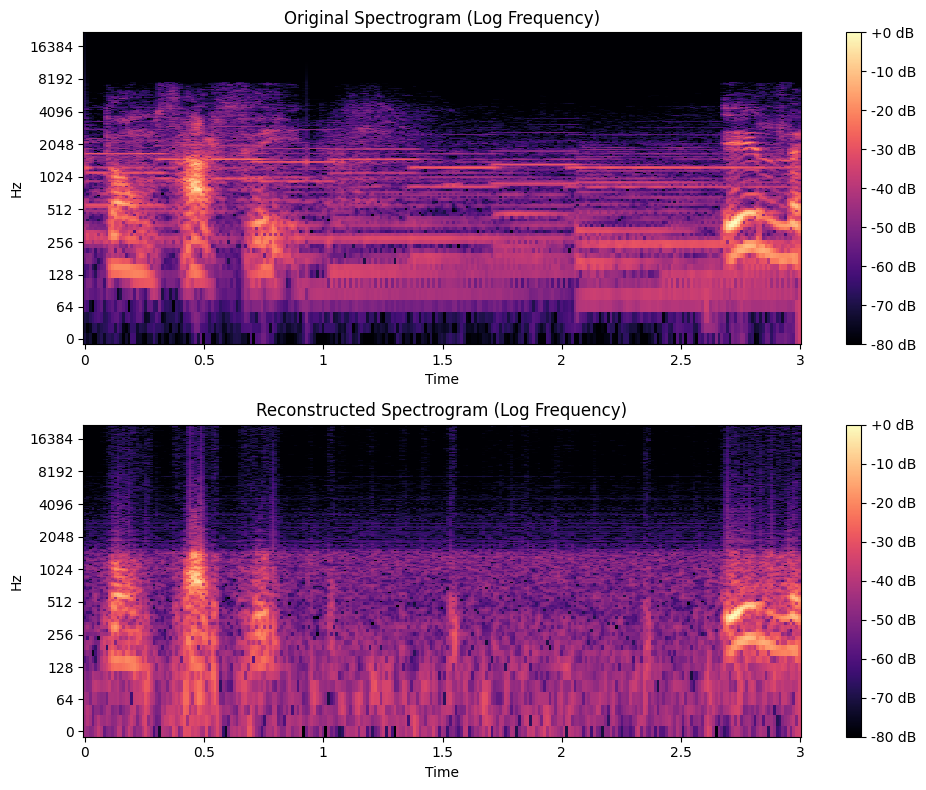

In [22]:
# Spectrogram Plotting
plt.figure(figsize=(10, 8))

# Original Spectrogram
plt.subplot(2, 1, 1)
D_orig = librosa.amplitude_to_db(np.abs(librosa.stft(full_original)), ref=np.max)
librosa.display.specshow(D_orig, sr=44100, x_axis='time', y_axis='log')
plt.title('Original Spectrogram (Log Frequency)')
plt.colorbar(format="%+2.0f dB")

# Reconstructed Spectrogram
plt.subplot(2, 1, 2)
D_recon = librosa.amplitude_to_db(np.abs(librosa.stft(full_recon)), ref=np.max)
librosa.display.specshow(D_recon, sr=44100, x_axis='time', y_axis='log')
plt.title('Reconstructed Spectrogram (Log Frequency)')
plt.colorbar(format="%+2.0f dB")

plt.tight_layout()
plt.show()